In [1]:
import torch
from torch.utils.data import DataLoader
from torch import nn
import torch.optim as optim

import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'functions')))
from dataset import ChestXrayDataset
from train import train
from evaluation import plot_results ,eval_on_metrics
import timm

c:\Users\Furkan\Miniconda3\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
IMAGE_PATH = "../archive/"
import glob

# Tüm alt klasörlerdeki jpg ve png dosyalarını alalım
image_paths = glob.glob(IMAGE_PATH + "**/images/*.[jp][pn]g", recursive=True)

print(f"Toplam {len(image_paths)} resim bulundu.")

Toplam 112120 resim bulundu.


In [3]:
TRAIN_PATH = '../data/AP_PA_Train.xlsx'
TEST_PATH = '../data/AP_PA_Test.xlsx'
VAL_PATH = '../data/AP_PA_Validation.xlsx'
LOG_PATH = 'logs/simclrv1fullyfinetune.log'
SAVE_PATH = 'models/simclrv1fullyfinetunebestmodel.pth'

In [4]:
num_classes = 2
EPOCHS = 30

In [5]:
# Önce kütüphaneyi kurmadıysan: pip install lightning-bolts

from pl_bolts.models.self_supervised import SimCLR

# Ağırlıkları doğrudan çeker (ResNet50)
weight_path = 'https://pl-bolts-weights.s3.us-east-2.amazonaws.com/simclr/bolts_simclr_imagenet/simclr_imagenet.ckpt'
simclr = SimCLR.load_from_checkpoint(weight_path, strict=False)

# Sadece backbone (ResNet50) kısmını alıp model değişkenine ata
backbone = simclr.encoder
backbone.fc = nn.Linear(in_features=2048, out_features=num_classes)

# Fix: Wrap model to handle list output from pl_bolts ResNet
class ModelWrapper(nn.Module):
    def __init__(self, model):
        super(ModelWrapper, self).__init__()
        self.model = model
    
    def forward(self, x):
        output = self.model(x)
        if isinstance(output, list) or isinstance(output, tuple):
            return output[0]
        return output

model = ModelWrapper(backbone)

c:\Users\Furkan\Miniconda3\envs\ml\Lib\site-packages\pl_bolts\__init__.py:11: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(numpy, tp_name):
c:\Users\Furkan\Miniconda3\envs\ml\Lib\site-packages\pl_bolts\models\self_supervised\amdim\amdim_module.py:34: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  "lr_options": generate_power_seq(LEARNING_RATE_CIFAR, 11),
c:\Users\Furkan\Miniconda3\envs\ml\Lib\site-packages\pl_bolts\models\self_supervised\amdim\amdim_module.py:92: UnderReviewWarning: The feature FeatureMapContrastiveTask is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(device)

cuda


In [7]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [8]:
train_dataset = ChestXrayDataset(TRAIN_PATH, image_paths,transform=transform)
val_dataset = ChestXrayDataset(TEST_PATH,image_paths, transform=transform)
test_dataset = ChestXrayDataset(VAL_PATH,image_paths, transform=transform)

In [9]:
print("Train size : ",len(train_dataset))
print("Validation size : ",len(val_dataset))
print("Test size : ",len(test_dataset))

Train size :  78566
Validation size :  16491
Test size :  17063


In [10]:
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True,num_workers=6)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=True,num_workers=6)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=True,num_workers=6)

In [11]:
train_losses, train_accuracies, val_losses, val_accuracies = train(model, train_dataloader, val_dataloader, criterion, optimizer, device,num_epochs=EPOCHS,patience=5,save_path=SAVE_PATH,log_path=LOG_PATH)

[2026-01-18 01:20:55] Training started.
Epoch 1/30 - Validation: 100%|██████████| 1031/1031 [00:59<00:00, 17.30it/s]
[2026-01-18 01:27:31] Epoch [1/30]
[2026-01-18 01:27:31]   Train Loss: 0.8586, Train Acc: 0.9895
[2026-01-18 01:27:31]   Val   Loss: 0.0399, Val   Acc: 0.9952
[2026-01-18 01:27:31]   Best model saved with val_loss: 0.0399


Epoch [1/30]
  Train Loss: 0.8586, Train Acc: 0.9895
  Val   Loss: 0.0399, Val   Acc: 0.9952
  Best model saved with val_loss: 0.0399


Epoch 2/30 - Validation: 100%|██████████| 1031/1031 [00:53<00:00, 19.45it/s]
[2026-01-18 01:33:45] Epoch [2/30]
[2026-01-18 01:33:45]   Train Loss: 0.0318, Train Acc: 0.9948
[2026-01-18 01:33:45]   Val   Loss: 0.0266, Val   Acc: 0.9955
[2026-01-18 01:33:45]   Best model saved with val_loss: 0.0266


Epoch [2/30]
  Train Loss: 0.0318, Train Acc: 0.9948
  Val   Loss: 0.0266, Val   Acc: 0.9955
  Best model saved with val_loss: 0.0266


Epoch 3/30 - Validation: 100%|██████████| 1031/1031 [01:02<00:00, 16.55it/s]
[2026-01-18 01:40:24] Epoch [3/30]
[2026-01-18 01:40:24]   Train Loss: 0.0244, Train Acc: 0.9951
[2026-01-18 01:40:24]   Val   Loss: 0.0230, Val   Acc: 0.9954
[2026-01-18 01:40:24]   Best model saved with val_loss: 0.0230


...

Epoch [8/30]
  Train Loss: 0.0070, Train Acc: 0.9980
  Val   Loss: 0.0269, Val   Acc: 0.9943
  No improvement. Early stopping counter: 3/5


Epoch 9/30 - Validation: 100%|██████████| 1031/1031 [00:55<00:00, 18.52it/s]
[2026-01-18 02:19:06] Epoch [9/30]
[2026-01-18 02:19:06]   Train Loss: 0.0057, Train Acc: 0.9984
[2026-01-18 02:19:06]   Val   Loss: 0.0288, Val   Acc: 0.9954
[2026-01-18 02:19:06]   No improvement. Early stopping counter: 4/5


Epoch [9/30]
  Train Loss: 0.0057, Train Acc: 0.9984
  Val   Loss: 0.0288, Val   Acc: 0.9954
  No improvement. Early stopping counter: 4/5


Epoch 10/30 - Validation: 100%|██████████| 1031/1031 [00:57<00:00, 18.07it/s]
[2026-01-18 02:25:18] Epoch [10/30]
[2026-01-18 02:25:18]   Train Loss: 0.0047, Train Acc: 0.9985
[2026-01-18 02:25:18]   Val   Loss: 0.0256, Val   Acc: 0.9956
[2026-01-18 02:25:18]   No improvement. Early stopping counter: 5/5
[2026-01-18 02:25:18]   Early stopping triggered. Training stopped.
[2026-01-18 02:25:18] 
========== BEST MODEL SUMMARY ==========
[2026-01-18 02:25:18] Best Epoch      : 5
[2026-01-18 02:25:18] Val Loss        : 0.0205
[2026-01-18 02:25:18] ========================================


Epoch [10/30]
  Train Loss: 0.0047, Train Acc: 0.9985
  Val   Loss: 0.0256, Val   Acc: 0.9956
  No improvement. Early stopping counter: 5/5
  Early stopping triggered. Training stopped.

========== BEST MODEL SUMMARY ==========
Best Epoch      : 5
Val Loss        : 0.0205


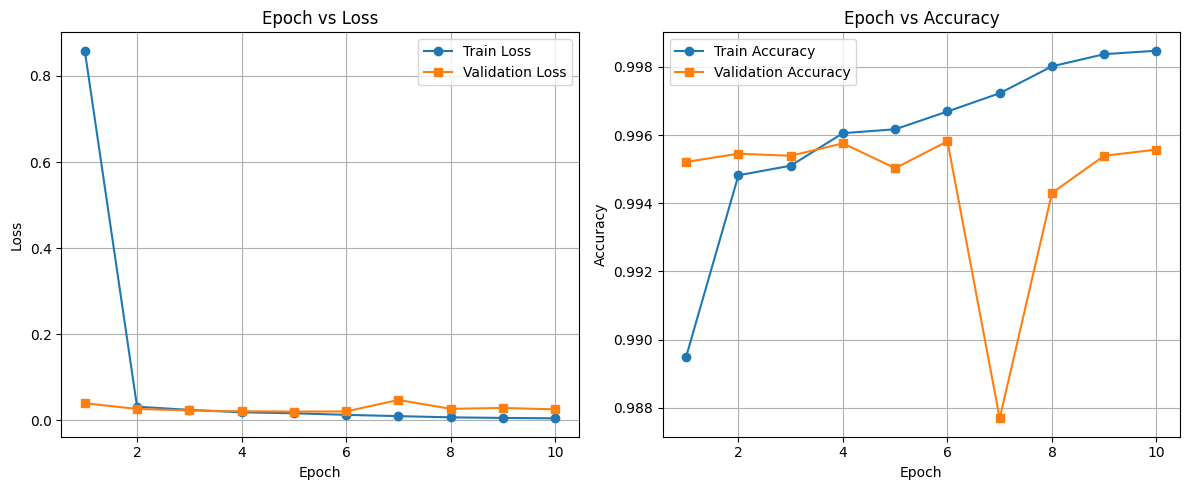

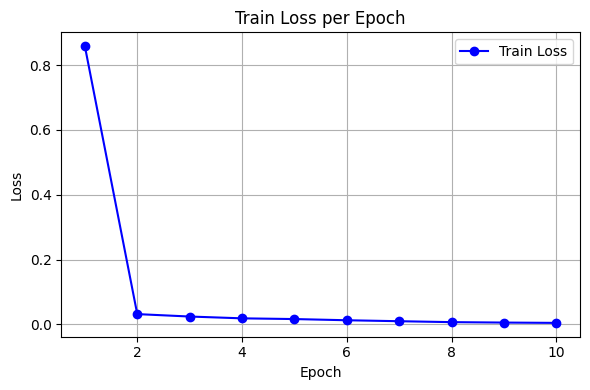

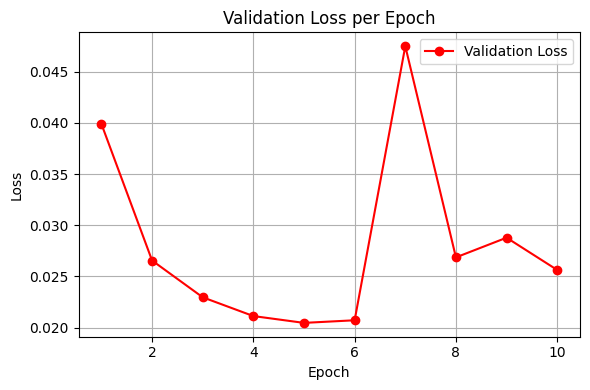

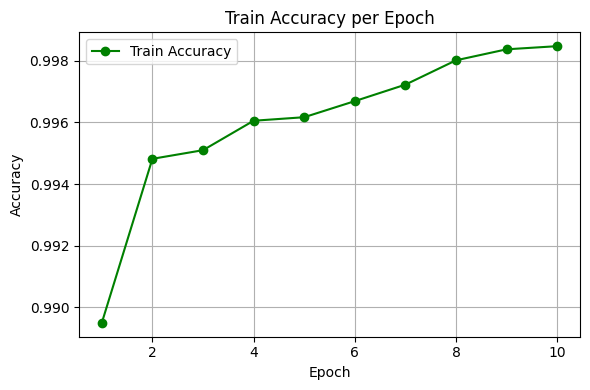

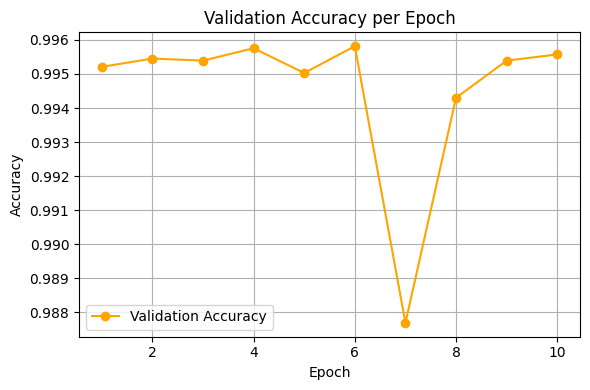

In [12]:
plot_results(train_losses, train_accuracies, val_losses, val_accuracies)

Evaluating: 100%|██████████| 1067/1067 [00:59<00:00, 18.06it/s]

Precision: 0.9937
Recall:    0.9978
F1 Score:  0.9958
AUC:       0.9991


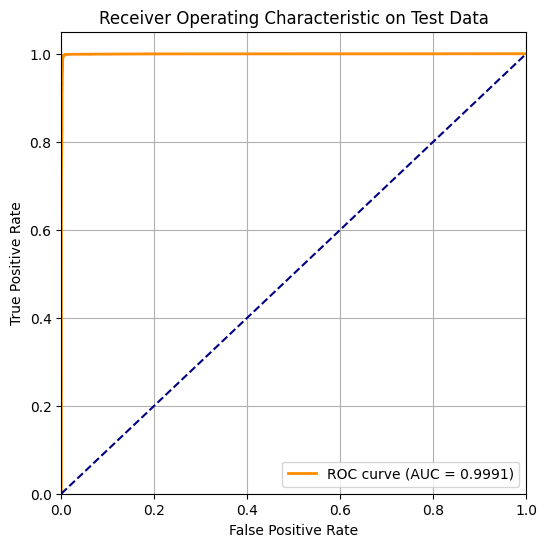

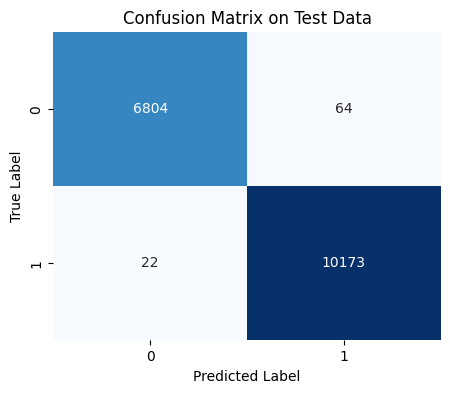

In [13]:
eval_on_metrics(model, test_dataloader)